In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
data = pd.read_csv("B.csv")
print(data.head())


   student_id  gender  ssc_percentage  hsc_percentage  degree_percentage  \
0           1    Male              53              79                 56   
1           2  Female              56              54                 59   
2           3    Male              94              83                 83   
3           4    Male              84              71                 87   
4           5    Male              58              88                 74   

   cgpa  entrance_exam_score  technical_skill_score  soft_skill_score  \
0  8.87                   50                     92                90   
1  6.78                   61                     51                99   
2  7.92                   91                     93                84   
3  6.57                   85                     60                72   
4  9.01                   73                     52                88   

   internship_count  live_projects  work_experience_months  certifications  \
0                 1       

In [14]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   ssc_percentage              5000 non-null   int64  
 3   hsc_percentage              5000 non-null   int64  
 4   degree_percentage           5000 non-null   int64  
 5   cgpa                        5000 non-null   float64
 6   entrance_exam_score         5000 non-null   int64  
 7   technical_skill_score       5000 non-null   int64  
 8   soft_skill_score            5000 non-null   int64  
 9   internship_count            5000 non-null   int64  
 10  live_projects               5000 non-null   int64  
 11  work_experience_months      5000 non-null   int64  
 12  certifications              5000 non-null   int64  
 13  attendance_percentage       5000 

,student_id,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,placement_status,salary_package_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,72.425800,71.910800,71.845200,7.678326,69.197800,69.651000,69.839600,1.987800,2.491800,11.982000,2.481000,79.433400,2.518400,0.173200,1.59589
std,1443.520003,13.199642,12.842781,10.013196,1.237084,17.325528,17.179704,17.170732,1.410975,1.704967,7.258114,1.719485,11.638585,1.721004,0.378458,3.77582
min,1.000000,50.000000,50.000000,55.000000,5.500000,40.000000,40.000000,40.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,0.000000,0.00000
25%,1250.750000,61.000000,61.000000,63.000000,6.617500,54.000000,55.000000,55.000000,1.000000,1.000000,6.000000,1.000000,69.000000,1.000000,0.000000,0.00000
50%,2500.500000,72.000000,72.000000,72.000000,7.700000,69.000000,70.000000,69.000000,2.000000,3.000000,12.000000,2.000000,80.000000,3.000000,0.000000,0.00000
75%,3750.250000,84.000000,83.000000,80.000000,8.750000,84.000000,84.000000,85.000000,3.000000,4.000000,18.000000,4.000000,89.000000,4.000000,0.000000,0.00000
max,5000.000000,95.000000,94.000000,89.000000,9.800000,99.000000,99.000000,99.000000,4.000000,5.000000,24.000000,5.000000,99.000000,5.000000,1.000000,14.99000


In [15]:
print(data.shape)

(5000, 18)


In [16]:
data.isnull().sum()

student_id                    0
gender                        0
ssc_percentage                0
hsc_percentage                0
degree_percentage             0
cgpa                          0
entrance_exam_score           0
technical_skill_score         0
soft_skill_score              0
internship_count              0
live_projects                 0
work_experience_months        0
certifications                0
attendance_percentage         0
backlogs                      0
extracurricular_activities    0
placement_status              0
salary_package_lpa            0
dtype: int64

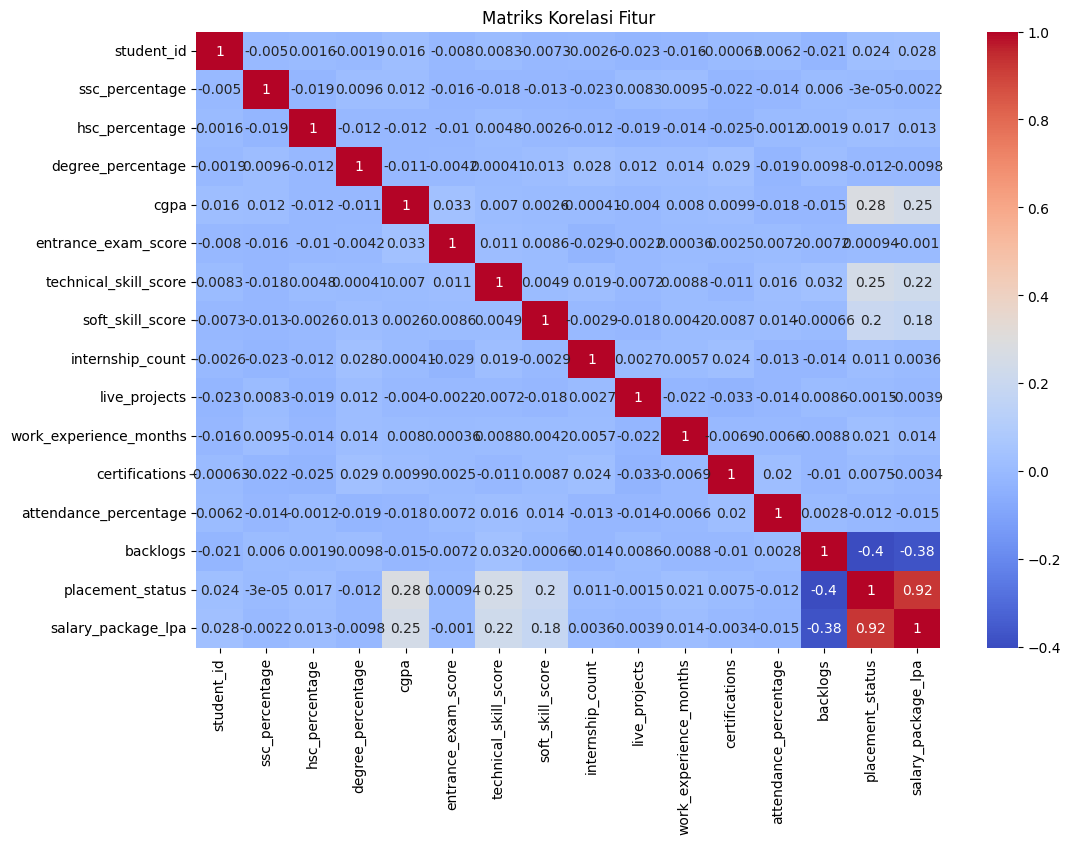

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Matriks Korelasi Fitur")
plt.show()

In [18]:
data.fillna(data.mean(numeric_only=True), inplace=True)
for col in data.select_dtypes(include='object'):
    data[col].fillna(data[col].mode()[0], inplace=True)

C:\Users\Cristopher\AppData\Local\Temp\ipykernel_22596\4098938354.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [19]:

data['total_skill_score'] = data['technical_skill_score'] + data['soft_skill_score']

data['experience_score'] = data['internship_count'] + data['live_projects'] + data['work_experience_months']

data['academic_score'] = (
    data['ssc_percentage'] +
    data['hsc_percentage'] +
    data['degree_percentage'] +
    data['cgpa'] * 25  #  making the gpa a percentage scale (1-100)
)

In [20]:
le = LabelEncoder()

data['gender'] = le.fit_transform(data['gender'])
data['extracurricular_activities'] = le.fit_transform(data['extracurricular_activities'])

In [21]:
X = data.drop(['student_id', 'placement_status', 'salary_package_lpa'], axis=1)
y_class = data['placement_status']
y_reg = data['salary_package_lpa']
#Classification Split
X_train, X_test, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)
#Reggresion Split
_, _, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Classification Models:

In [ ]:
#Logistic Reggression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train_c)

pred_lr = lr.predict(X_test_scaled)

print("LogReg Accuracy:", accuracy_score(y_test_c, pred_lr))
print(classification_report(y_test_c, pred_lr))

LogReg Accuracy: 0.876
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       801
           1       0.75      0.57      0.65       199

    accuracy                           0.88      1000
   macro avg       0.82      0.76      0.79      1000
weighted avg       0.87      0.88      0.87      1000



In [ ]:
#Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train_c)

pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test_c, pred_rf))

RF Accuracy: 0.999


In [ ]:
#SVM
svm = SVC()
svm.fit(X_train_scaled, y_train_c)

pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test_c, pred_svm))

SVM Accuracy: 0.943


Reggression Models:


In [ ]:
#Linear Reggression
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train_r)

pred_lin = linreg.predict(X_test_scaled)

print("RMSE:", np.sqrt(mean_squared_error(y_test_r, pred_lin)))
print("R2:", r2_score(y_test_r, pred_lin))

RMSE: 3.2315565137842612
R2: 0.30225022306920224


In [ ]:

#Random Forest
rf_reg = RandomForestRegressor()
rf_reg.fit(X_train, y_train_r)

pred_rf = rf_reg.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test_r, pred_rf)))
print("R2:", r2_score(y_test_r, pred_rf))

In [28]:
#SVR
svr = SVR()
svr.fit(X_train_scaled, y_train_r)

pred_svr = svr.predict(X_test_scaled)

print("RMSE:", np.sqrt(mean_squared_error(y_test_r, pred_svr)))
print("R2:", r2_score(y_test_r, pred_svr))

RMSE: 3.144214609944893
R2: 0.3394578154214881


In [29]:
results_class = pd.DataFrame({
    "Model": ["LogReg", "RF", "SVM"],
    "Accuracy": [
        accuracy_score(y_test_c, pred_lr),
        accuracy_score(y_test_c, pred_rf),
        accuracy_score(y_test_c, pred_svm)
    ]
})

results_class

,Model,Accuracy
0,LogReg,0.876
1,RF,0.999
2,SVM,0.943


In [30]:
results_reg = pd.DataFrame({
    "Model": ["Linear", "RF", "SVR"],
    "R2": [
        r2_score(y_test_r, pred_lin),
        r2_score(y_test_r, pred_rf),
        r2_score(y_test_r, pred_svr)
    ]
})

results_reg

,Model,R2
0,Linear,0.302250
1,RF,0.012150
2,SVR,0.339458


In [31]:
import sys
print(sys.executable)

c:\Users\Cristopher\anaconda3\python.exe
